# Planar HDiv-VIM for electric machines — nonlinear iron, rotation sweep, torque, eddy coupling, induction

**What this shows (executed, 2026-07-03).** The planar (2D motor cross-section) HDiv-VIM layer
promoted into `radia.vim` (`PlanarDemagBody` / `hdiv_demag_solve` on a 2D mesh /
`maxwell_torque_circle`), taken through the full machine pipeline:

1. **Nonlinear iron** — disk deep-saturation sweep vs the analytic fixed point `M = Mof(H0 − M/2)`
   (disk demag factor 1/2 exact);
2. **Rotation sweep + torque** — ellipse reluctance torque, three ways (closed form / volume torque
   / Maxwell-stress circle), with the demag operator **built once** for the whole sweep (a rigid
   rotor rotation is only a new applied field — no remesh, no air mesh);
3. **Salient-bar reluctance motor** — 6-wire sin-distribution stator + saturating bar rotor,
   torque-angle curve vs an all-in-one **exact-Newton** nonlinear FEM reference (closed-form
   `nu(B)` inversion; coil disks curved + measured-area current normalization);
4. **Induction physics** — solid conducting cylinder in a uniform rotating field vs the
   boundary-matching **Bessel closed form** (torque-slip curve through its peak);
5. **Mini cage induction machine** — VIM iron core + reduced complex-FEM bar ring, staggered
   weak coupling, torque-slip vs an all-in-one frozen-secant FEM.

The squirrel-cage split maps exactly onto the weak-coupling architecture (laminated core =
magnetic/non-conducting → VIM; cage bars = conducting/non-magnetic → reduced FEM; stator =
analytic rotating field). What does **not** fit this split is a *nonlinear* solid-iron rotor
(conductor = magnetic body in one region) — that is the eddy-current-VIM research direction
(`docs/hdiv_vim/README.md` §9). A *linear* magnetic conductor DOES fit — its `mu_r` goes into the
reduced FEM reluctivity (case 4 verifies `mu_r=10` against the closed form).

Solver: `radia.vim` (this repo). References and coupling machinery:
[`planar_vim_motor_helpers.py`](planar_vim_motor_helpers.py). Goldens:
`validation_test/feec/test_hdiv_vim_2d_solve.py` (+ `test_hdiv_vim_2d_wiring.py`).
Research lineage and the reference-side bug hunt (5 reference bugs + 3 coupling-layer bugs,
0 in the shipped Gram): memory `hdiv-vim-tri-quad-motor`.

In [1]:
import json, platform, time
import numpy as np
import matplotlib.pyplot as plt
import ngsolve as ng
from netgen.occ import WorkPlane, OCCGeometry
import radia
from radia.vim import hdiv_demag_solve, PlanarDemagBody, maxwell_torque_circle
import planar_vim_motor_helpers as H

RESULTS = {"radia_version": radia.__version__, "platform": platform.platform()}
print("radia", radia.__version__, "| numpy", np.__version__)

radia 4.95.5 | numpy 2.4.6


## 1. Nonlinear iron — disk deep-saturation vs the analytic fixed point

One call: `hdiv_demag_solve(mesh2d, bh_table=..., H_ext=...)`. The saturating law
`M(H) = chi0 H / (1 + chi0 H / Msat)` (chi0 = 1000, Msat = 1.2 MA/m) is passed as a `[[H, B]]`
table; the reference is the uniform-body fixed point `M = Mof(H0 − M/2)` (disk demag `D = 1/2`
exact). The solver is the scalar-secant-chi Picard with safeguarded Anderson(1) — it converges
from the linear regime through deep saturation (M/Msat → 1).

In [2]:
wp = WorkPlane().Circle(0, 0, 1.0).Face()
mesh_disk = ng.Mesh(OCCGeometry(wp, dim=2).GenerateMesh(maxh=0.3))
tab = H.bh_table()
rows = []
for H0 in (1e3, 1e4, 1e5, 1e6):
    with ng.TaskManager():
        res = hdiv_demag_solve(mesh_disk, None, ng.CoefficientFunction((H0, 0.0)), bh_table=tab)
    Mref = H.fixed_point_disk(H0)
    rel = abs(res["M_avg"][0] - Mref) / Mref
    rows.append({"H0": H0, "M_vim": res["M_avg"][0], "M_ref": Mref, "rel": rel,
                 "iters": res["iters"], "M_over_Msat": res["M_avg"][0] / H.MSAT})
    print(f"H0={H0:8.0e}: M={res['M_avg'][0]:12.1f}  ref={Mref:12.1f}  rel={rel:.2e}"
          f"  M/Msat={res['M_avg'][0]/H.MSAT:.3f}  picard={res['iters']}")
    assert rel < 1e-3
RESULTS["disk_deep_saturation"] = rows

H0=   1e+03: M=      1996.6  ref=      1996.0  rel=3.01e-04  M/Msat=0.002  picard=4


H0=   1e+04: M=     19965.4  ref=     19959.4  rel=3.01e-04  M/Msat=0.017  picard=6


H0=   1e+05: M=    199581.2  ref=    199521.4  rel=3.00e-04  M/Msat=0.166  picard=10


H0=   1e+06: M=   1196423.0  ref=   1196426.7  rel=3.08e-06  M/Msat=0.997  picard=10


## 2. Rotation sweep + torque — ellipse, three ways, demag operator built once

The reluctance-torque anchor with a closed form: ellipse 2:1 (`N_a = 1/3`, `N_b = 2/3`), linear
`chi = 1000`. Torque three ways: closed form, volume torque `mu0 A (M × H0)`, and the
Maxwell-stress circle evaluated on the **analytic charge field** (`PlanarDemagBody.H_at`).
`N = B^T G B` is geometry-only, so the sweep reuses it — each angle is one projection + one
solve.

N built once: 0.31 s;  per-angle solve: 27 ms  (no rebuild, no remesh)
3-way torque agreement: volume 0.68%, Maxwell circle 1.49% of Tmax


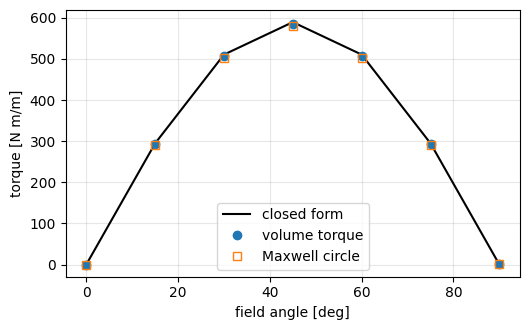

In [3]:
a_el, b_el = 0.2, 0.1
Na, Nb = b_el/(a_el+b_el), a_el/(a_el+b_el)
area = np.pi*a_el*b_el
chi, H0 = 1000.0, 1e5
wp = WorkPlane().Ellipse(a_el, b_el).Face()
mesh_el = ng.Mesh(OCCGeometry(wp, dim=2).GenerateMesh(maxh=b_el/3))
with ng.TaskManager():
    t0 = time.perf_counter()
    body = PlanarDemagBody(mesh_el)
    t_build = time.perf_counter() - t0
angles = np.arange(0.0, 91.0, 15.0)
rows, t_ang = [], []
for th in angles:
    Ha, Hb = H0*np.cos(np.radians(th)), H0*np.sin(np.radians(th))
    with ng.TaskManager():
        t0 = time.perf_counter()
        m = body.solve_linear(chi, body.project(ng.CoefficientFunction((Ha, Hb))))
        t_ang.append(time.perf_counter() - t0)
    Ma, Mb = chi*Ha/(1+chi*Na), chi*Hb/(1+chi*Nb)
    T_ref = H.MU0*area*(Ma*Hb - Mb*Ha)
    Mx, My = body.M_avg(m)
    T_vol = H.MU0*area*(Mx*Hb - My*Ha)
    def H_tot(P, Ha=Ha, Hb=Hb, m=m):
        Hf = body.H_at(P, m); Hf[:, 0] += Ha; Hf[:, 1] += Hb
        return Hf
    T_mx = maxwell_torque_circle(H_tot, 0.3)
    rows.append({"theta": th, "T_ref": T_ref, "T_vol": T_vol, "T_mx": T_mx})
Tm = max(abs(r["T_ref"]) for r in rows)
ev = max(abs(r["T_vol"]-r["T_ref"]) for r in rows)/Tm
em = max(abs(r["T_mx"]-r["T_ref"]) for r in rows)/Tm
print(f"N built once: {t_build:.2f} s;  per-angle solve: {1e3*np.mean(t_ang):.0f} ms  "
      f"(no rebuild, no remesh)")
print(f"3-way torque agreement: volume {ev:.2%}, Maxwell circle {em:.2%} of Tmax")
assert ev < 1e-2 and em < 2e-2
RESULTS["ellipse_torque"] = {"rows": rows, "t_build_s": t_build,
                             "t_per_angle_ms": 1e3*float(np.mean(t_ang)),
                             "max_rel_volume": ev, "max_rel_maxwell": em}
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.plot([r["theta"] for r in rows], [r["T_ref"] for r in rows], "k-", label="closed form")
ax.plot([r["theta"] for r in rows], [r["T_vol"] for r in rows], "o", label="volume torque")
ax.plot([r["theta"] for r in rows], [r["T_mx"] for r in rows], "s", mfc="none", label="Maxwell circle")
ax.set_xlabel("field angle [deg]"); ax.set_ylabel("torque [N m/m]")
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout(); display(fig); plt.close(fig)

## 3. Salient-bar reluctance motor — torque-angle curve vs an exact-Newton FEM

A machine-like case with **no closed form**: 6 wires approximating the 2-pole sheet
`K(phi) = K0 sin(phi)` (knee-level drive) + a saturating salient bar rotor. The VIM works in the
rotor frame (wires rotated per angle; the Gram reused); the reference is an all-in-one nonlinear
A_z FEM solved by a true Newton on the closed-form `nu(|B|)` (quadratic convergence, 6–9 iters).
Two reference-side traps are baked into the helper: coil disks must be **curved** and their
current normalized by the **measured** disk area (an inscribed 12-gon under-carries ~5% →
torque −10%).

th=  0.0: T_vim=    11.89  T_fem=   -25.53  N m/m  (picard 68, newton 9, fem ndof 6669)


th= 15.0: T_vim= -1807.26  T_fem= -1801.83  N m/m  (picard 50, newton 9, fem ndof 6645)


th= 30.0: T_vim= -3473.00  T_fem= -3498.29  N m/m  (picard 54, newton 9, fem ndof 6773)


th= 45.0: T_vim= -4243.98  T_fem= -4230.31  N m/m  (picard 44, newton 9, fem ndof 6737)


th= 60.0: T_vim= -3509.55  T_fem= -3538.32  N m/m  (picard 42, newton 8, fem ndof 6825)


th= 75.0: T_vim= -1774.88  T_fem= -1782.80  N m/m  (picard 39, newton 8, fem ndof 6645)


th= 90.0: T_vim=    -0.34  T_fem=    53.98  N m/m  (picard 40, newton 7, fem ndof 6681)
torque-angle: mean 0.58%  max 1.28% of Tmax


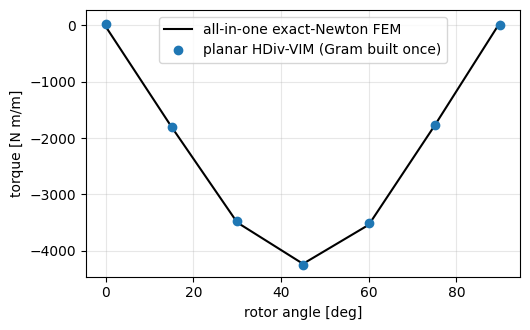

In [4]:
wp = WorkPlane().RectangleC(H.A_BAR, H.B_BAR).Face()
mesh_bar = ng.Mesh(OCCGeometry(wp, dim=2).GenerateMesh(maxh=0.02))
with ng.TaskManager():
    body = PlanarDemagBody(mesh_bar)
angles = np.arange(0.0, 91.0, 15.0)
rows = []
for th in angles:
    W = H.wire_pos(th)
    with ng.TaskManager():
        m, chi_e, itn, res_nl = body.solve_nonlinear(H.M_of_h, H.chi_sec,
                                                     body.project(H.H_wires_cf(W)))
    def H_tot(P, W=W, m=m):
        return body.H_at(P, m) + H.H_wires_np(P, W)
    T_vim = maxwell_torque_circle(H_tot, H.RC_A)
    with ng.TaskManager():
        T_fem, ndof, it_newton = H.fem_reference_bar(th)
    rows.append({"theta": th, "T_vim": T_vim, "T_fem": T_fem, "picard": itn,
                 "newton": it_newton})
    print(f"th={th:5.1f}: T_vim={T_vim:9.2f}  T_fem={T_fem:9.2f}  N m/m"
          f"  (picard {itn}, newton {it_newton}, fem ndof {ndof})")
Tv = np.array([r["T_vim"] for r in rows]); Tf = np.array([r["T_fem"] for r in rows])
Tmax = np.abs(Tf).max(); rel = np.abs(Tv-Tf)/Tmax
print(f"torque-angle: mean {rel.mean():.2%}  max {rel.max():.2%} of Tmax")
assert rel.max() < 0.05
RESULTS["salient_bar_motor"] = {"rows": rows, "mean_rel": float(rel.mean()),
                                "max_rel": float(rel.max())}
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.plot(angles, Tf, "k-", label="all-in-one exact-Newton FEM")
ax.plot(angles, Tv, "o", label="planar HDiv-VIM (Gram built once)")
ax.set_xlabel("rotor angle [deg]"); ax.set_ylabel("torque [N m/m]")
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout(); display(fig); plt.close(fig)

## 4. Induction physics — rotating-field conducting cylinder vs the Bessel closed form

The canonical induction surrogate: a solid conducting cylinder in a uniform rotating field at
slip frequency. The boundary-matching closed form gives the time-averaged torque
`T = 2 pi H0 Re(beta)` (`beta` = the exterior dipole coefficient; circle-radius independence is
analytic). The torque-slip curve rises, peaks near `|k| a ≈ 2`, and falls — reproduced by the
reduced complex A_z solve. The `mu_r = 10` point verifies that a LINEAR magnetic conductor lives
wholly in the reduced-FEM side (with the `-(nu - nu0) grad(A_s)` split residual).

w=    0.3: T_analytic=   2.0606  T_reduced=   2.0588  N m/m


w=    1.0: T_analytic=   6.8344  T_reduced=   6.8285  N m/m


w=    3.0: T_analytic=  19.6393  T_reduced=  19.6257  N m/m


w=   10.0: T_analytic=  44.5779  T_reduced=  44.5953  N m/m


w=   30.0: T_analytic=  39.5354  T_reduced=  39.6199  N m/m


w=  100.0: T_analytic=  23.7370  T_reduced=  23.8139  N m/m


w=  300.0: T_analytic=  14.4278  T_reduced=  14.4861  N m/m


torque-slip: max rel 0.19%;  mu_r=10 point: analytic 51.78 vs reduced 51.66 (0.23%)


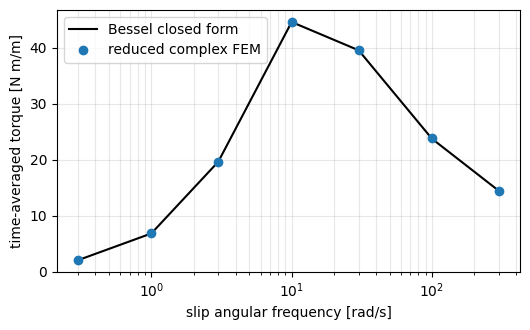

In [5]:
omegas = np.array([0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0])
rows = []
for w in omegas:
    Ta = H.cylinder_analytic_T(w)
    delta = np.sqrt(2.0/(H.MU0*H.SIGMA_CYL*w))
    with ng.TaskManager():
        Tn = H.cylinder_reduced_T(w, maxh_cond=min(0.004, delta/3))
    rows.append({"omega": w, "T_analytic": Ta, "T_reduced": Tn})
    print(f"w={w:7.1f}: T_analytic={Ta:9.4f}  T_reduced={Tn:9.4f}  N m/m")
Tmax = max(abs(r["T_analytic"]) for r in rows)
errs = [abs(r["T_reduced"]-r["T_analytic"])/Tmax for r in rows]
with ng.TaskManager():
    Ta10 = H.cylinder_analytic_T(10.0, mu_r=10.0)
    Tn10 = H.cylinder_reduced_T(10.0, mu_r=10.0)
print(f"torque-slip: max rel {max(errs):.2%};  mu_r=10 point: analytic {Ta10:.2f} vs "
      f"reduced {Tn10:.2f} ({abs(Tn10-Ta10)/abs(Ta10):.2%})")
assert max(errs) < 0.02 and abs(Tn10-Ta10)/abs(Ta10) < 0.03
RESULTS["rotating_cylinder"] = {"rows": rows, "max_rel": max(errs),
                                "mu_r10": {"analytic": Ta10, "reduced": Tn10}}
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.semilogx([r["omega"] for r in rows], [r["T_analytic"] for r in rows], "k-",
            label="Bessel closed form")
ax.semilogx([r["omega"] for r in rows], [r["T_reduced"] for r in rows], "o",
            label="reduced complex FEM")
ax.set_xlabel("slip angular frequency [rad/s]"); ax.set_ylabel("time-averaged torque [N m/m]")
ax.grid(alpha=0.3, which="both"); ax.legend(); fig.tight_layout(); display(fig); plt.close(fig)

## 5. Mini cage induction machine — VIM core + reduced-FEM bar ring, torque-slip

The architecture-fit demonstration: a saturating iron core disk (VIM, non-conducting — the
laminated-core role) + 8 aluminum bars (reduced complex A_z FEM) in a uniform rotating field, in
the rotor frame at slip frequency. Staggered weak coupling, iterated **until** `dM < 1e-3` (at
high slip the bar reaction grows with the bar currents, so a fixed iteration count stops
converging). The iron's conjugate potential on the bar ring uses the **single-valued polar
construction** — the plain `atan2` formula has a branch cut along the −x ray of every charge,
and a ring that surrounds the body crosses them. Reference: all-in-one frozen-secant FEM
(box 32×32; an 8×8 box biases 2D log-tail losses ~15%).

slip w=  3.0: T_coupled=   8.6198  T_allinone=   8.6926  N m/m  rel= 0.84%  (8 staggers, dM=3.8e-04)


slip w= 10.0: T_coupled=  28.0728  T_allinone=  28.2878  N m/m  rel= 0.76%  (8 staggers, dM=4.7e-04)


slip w= 30.0: T_coupled=  70.0711  T_allinone=  70.4718  N m/m  rel= 0.57%  (8 staggers, dM=2.6e-04)
cage torque-slip: max rel 0.57% of Tmax


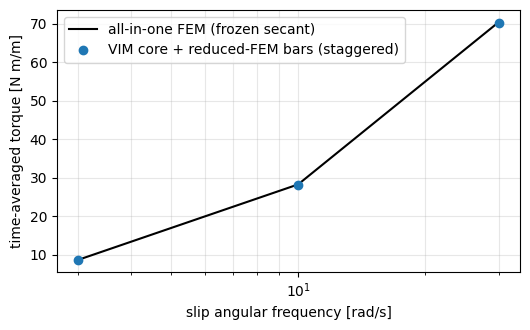

In [6]:
wp = WorkPlane().Circle(0, 0, H.R_CORE).Face()
mesh_core = ng.Mesh(OCCGeometry(wp, dim=2).GenerateMesh(maxh=H.R_CORE/4))
with ng.TaskManager():
    core = PlanarDemagBody(mesh_core)
slips = np.array([3.0, 10.0, 30.0])
rows = []
for w in slips:
    with ng.TaskManager():
        T_c, hist = H.cage_coupled_slip(core, w)
        T_f, loss_f, ndof = H.cage_allinone_slip(w)
    rel = abs(T_c - T_f)/abs(T_f)
    rows.append({"omega": w, "T_coupled": T_c, "T_allinone": T_f, "rel": rel,
                 "staggers": len(hist), "dM_final": hist[-1]["dM"]})
    print(f"slip w={w:5.1f}: T_coupled={T_c:9.4f}  T_allinone={T_f:9.4f}  N m/m"
          f"  rel={rel:6.2%}  ({len(hist)} staggers, dM={hist[-1]['dM']:.1e})")
Tmax = max(abs(r["T_allinone"]) for r in rows)
mrel = max(abs(r["T_coupled"]-r["T_allinone"])/Tmax for r in rows)
print(f"cage torque-slip: max rel {mrel:.2%} of Tmax")
assert mrel < 0.05
RESULTS["mini_cage"] = {"rows": rows, "max_rel": mrel}
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.semilogx([r["omega"] for r in rows], [r["T_allinone"] for r in rows], "k-",
            label="all-in-one FEM (frozen secant)")
ax.semilogx([r["omega"] for r in rows], [r["T_coupled"] for r in rows], "o",
            label="VIM core + reduced-FEM bars (staggered)")
ax.set_xlabel("slip angular frequency [rad/s]"); ax.set_ylabel("time-averaged torque [N m/m]")
ax.grid(alpha=0.3, which="both"); ax.legend(); fig.tight_layout(); display(fig); plt.close(fig)

## 6. Status and pointers

**Shipped by this line of work** (all golden-locked in `validation_test/feec/`):
the planar solve layer (`radia.vim._vim2d`: `PlanarDemagBody`, `solve_planar_demag`,
`maxwell_torque_circle`; dispatched by `hdiv_demag_solve` on `mesh.dim == 2`), the 2D charge Gram
(`test_hdiv_vim_2d_wiring.py`), and this notebook's gates (`test_hdiv_vim_2d_solve.py`).

**Recorded in the research layer** (memory `hdiv-vim-tri-quad-motor`; not re-executed here to
keep the notebook bounded): the nonlinear-iron ↔ eddy-plate stagger verified against an
all-in-one reference at 1.8% (linear) / 2.5% (knee) / 3.0% (deep saturation) with 4-iteration
convergence at every drive; the full mini-cage sweep to slip 100 (max 0.5%); and the
reference-side bug catalog (coil-disk polygon current deficit; collar truncation must move
EVERY boundary edge; the conjugate-potential sign and branch-cut lessons — now permanent gates).

**Open next steps**: wedge elements (extruded 3D motor stacks), the NGSolve+AGE lane comparison
(`radia_mcp.motor` dual-lane contract — this notebook's cases live in the
`hdiv_vim_reduced_fem` lane), rotor-frame transient/hysteresis, and the nonlinear solid-iron
rotor via the eddy-current VIM research direction.

In [7]:
print(json.dumps({k: v for k, v in RESULTS.items() if k != "rows"}, indent=1,
                 default=lambda o: float(o) if hasattr(o, "item") else str(o))[:3000])

{
 "radia_version": "4.95.5",
 "platform": "Windows-2022Server-10.0.20348-SP0",
 "disk_deep_saturation": [
  {
   "H0": 1000.0,
   "M_vim": 1996.6012840799206,
   "M_ref": 1996.0013462089573,
   "rel": 0.00030056987291251293,
   "iters": 4,
   "M_over_Msat": 0.0016638344033999338
  },
  {
   "H0": 10000.0,
   "M_vim": 19965.404061155117,
   "M_ref": 19959.405994480112,
   "rel": 0.00030051328564908433,
   "iters": 6,
   "M_over_Msat": 0.016637836717629265
  },
  {
   "H0": 100000.0,
   "M_vim": 199581.19917032152,
   "M_ref": 199521.3777725824,
   "rel": 0.00029982450205059567,
   "iters": 10,
   "M_over_Msat": 0.16631766597526793
  },
  {
   "H0": 1000000.0,
   "M_vim": 1196422.9916173543,
   "M_ref": 1196426.6807211721,
   "rel": 3.083434929398576e-06,
   "iters": 10,
   "M_over_Msat": 0.9970191596811286
  }
 ],
 "ellipse_torque": {
  "rows": [
   {
    "theta": 0.0,
    "T_ref": 0.0,
    "T_vol": -0.20103183774216157,
    "T_mx": -0.19938928274595336
   },
   {
    "theta": 15.0,
  